# MSCFEE 620 Derivative Pricing - Group Work Project Report
Scope:

- Q1-Q4: we explain put-call parity for European options and why American options need bounds instead of the same equality.
- Q5-Q7: we price European calls and puts, compute Delta, and test what happens when volatility increases.
- Q8-Q10: we repeat the same work for American options and explain the early-exercise effect.
- Q11-Q14: we check parity and compare European versus American prices.
- Q15-Q18: we use a trinomial tree across five strikes.
- Q19-Q24: we plot the price patterns and check parity/bounds visually and numerically.
- Q25-Q27: we build Delta-hedging examples for European, American, and Asian puts.

Unless stated otherwise, the Step 1 and Step 2 pricing sections use:

\[
S_0=100,\quad r=5\%,\quad \sigma=20\%,\quad T=3\text{ months}=0.25.
\]

We assume the stock pays no dividends. All option prices in answer tables are in dollars and rounded to the nearest cent unless the table needs extra precision.


## Executive Summary

We use three workhorses in this project: binomial trees, trinomial trees, and Monte Carlo simulation. The trees are useful when the option value can be pushed backward through nodes. Monte Carlo is more natural for the Asian option because the payoff depends on the whole path, not only the final stock price.

Our main results are:

- European put-call parity works cleanly because exercise happens only at maturity.
- American options do not obey the same exact parity equation; we check no-arbitrage bounds instead.
- In a no-dividend setting, American calls line up with European calls because early exercise throws away time value.
- American puts are more valuable than European puts because early exercise can be useful when the put is deep in the money.
- Higher volatility raises both call and put values because optionality likes a wider range of possible future prices.
- Delta hedging is not a one-time trade. We rebalance the stock position as the tree or simulated path moves.


## How We Approach the Project

We keep one simple workflow throughout the report:

1. We write down the financial rule first, so the reader knows what is being tested.
2. We compute the numbers with transparent code rather than treating the model as a black box.
3. We read the output like a trader or risk manager would: does the price move in the right direction, does the hedge sign make sense, and does the parity check pass?

This keeps the report grounded. The formulas matter, but we use them to explain pricing behavior instead of reciting them like textbook decoration.


## Setup

We keep the numerical setup deliberately plain. For vanilla options, we use recombining binomial and trinomial trees because they make the pricing logic visible: move stock prices forward, put payoffs at the end, then discount values backward. Later, we reuse the same tree logic for Delta hedging.

For the Asian put in Q27, we switch to Monte Carlo simulation. That is not because trees are bad. It is because an Asian payoff depends on the average price along the path, so the final stock price alone is no longer enough information.


In [1]:
import math
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

S0 = 100.0
r = 0.05
sigma = 0.20
T = 0.25
K_ATM = 100.0

BINOMIAL_STEPS = 1000
TRINOMIAL_STEPS = 1000


## Pricing Methodology

### Binomial tree

For a tree with \(N\) steps, we set

\[
\Delta t = \frac{T}{N}, \qquad
u=e^{\sigma\sqrt{\Delta t}}, \qquad
d=\frac{1}{u}.
\]

The risk-neutral probability is

\[
p=\frac{e^{r\Delta t}-d}{u-d}.
\]

In plain words, we let the stock move up or down at each step, but we price the option under the risk-neutral measure. That means we discount expected future payoffs at the risk-free rate instead of using the stock's real-world expected return.

At maturity, the option value is just its payoff:

\[
C_T=\max(S_T-K,0), \qquad P_T=\max(K-S_T,0).
\]

For a European option, we move backward through the tree using

\[
V_t=e^{-r\Delta t}\left[pV_u+(1-p)V_d\right].
\]

For an American option, we add one extra check at every node: should the holder continue, or exercise immediately?

\[
V_t=\max\left(\text{intrinsic value},\ e^{-r\Delta t}\left[pV_u+(1-p)V_d\right]\right).
\]

That max operator is where the American early-exercise value enters the report.

### Trinomial tree

The trinomial tree lets the stock move up, stay in the middle, or move down. We use a recombining version with

\[
u=e^{\sigma\sqrt{2\Delta t}},
\]

and risk-neutral probabilities chosen so the one-step drift and variance match the model inputs. The backward recursion is

\[
V_t=e^{-r\Delta t}\left[p_uV_u+p_mV_m+p_dV_d\right].
\]

For American options, we use the same immediate-exercise comparison as in the binomial tree. So the logic stays the same; the only difference is that each node has three branches instead of two.


In [2]:
def payoff(stock, strike, option_type):
    stock = np.asarray(stock, dtype=float)
    if option_type == "call":
        return np.maximum(stock - strike, 0.0)
    if option_type == "put":
        return np.maximum(strike - stock, 0.0)
    raise ValueError("option_type must be 'call' or 'put'")


def binomial_tree_price(S0, K, r, sigma, T, steps, option_type, american=False):
    """CRR binomial option price and time-0 delta."""
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    disc = math.exp(-r * dt)
    p = (math.exp(r * dt) - d) / (u - d)

    if not 0.0 <= p <= 1.0:
        raise ValueError(f"Risk-neutral probability outside [0, 1]: {p}")

    j = np.arange(steps + 1)
    stock = S0 * (u ** j) * (d ** (steps - j))
    values = payoff(stock, K, option_type)
    first_step_values = None

    for step in range(steps - 1, -1, -1):
        values = disc * (p * values[1:] + (1.0 - p) * values[:-1])

        if american:
            j = np.arange(step + 1)
            stock = S0 * (u ** j) * (d ** (step - j))
            values = np.maximum(values, payoff(stock, K, option_type))

        if step == 1:
            first_step_values = values.copy()

    price = float(values[0])
    delta = None
    if first_step_values is not None:
        s_down = S0 * d
        s_up = S0 * u
        delta = float((first_step_values[1] - first_step_values[0]) / (s_up - s_down))

    return {
        "price": price,
        "delta": delta,
        "steps": steps,
        "u": u,
        "d": d,
        "p": p,
    }


def trinomial_tree_price(S0, K, r, sigma, T, steps, option_type, american=False):
    """Recombining trinomial tree option price."""
    dt = T / steps
    disc = math.exp(-r * dt)
    u = math.exp(sigma * math.sqrt(2.0 * dt))

    a = math.exp(r * dt / 2.0)
    b = math.exp(sigma * math.sqrt(dt / 2.0))
    c = 1.0 / b
    pu = ((a - c) / (b - c)) ** 2
    pdn = ((b - a) / (b - c)) ** 2
    pm = 1.0 - pu - pdn

    if min(pu, pm, pdn) < -1e-12:
        raise ValueError(f"Invalid trinomial probabilities: pu={pu}, pm={pm}, pd={pdn}")

    j = np.arange(-steps, steps + 1)
    stock = S0 * (u ** j)
    values = payoff(stock, K, option_type)

    for step in range(steps - 1, -1, -1):
        values = disc * (pdn * values[:-2] + pm * values[1:-1] + pu * values[2:])

        if american:
            j = np.arange(-step, step + 1)
            stock = S0 * (u ** j)
            values = np.maximum(values, payoff(stock, K, option_type))

    return {
        "price": float(values[0]),
        "steps": steps,
        "pu": pu,
        "pm": pm,
        "pd": pdn,
    }


def cents(x):
    return round(float(x), 2)


def four_decimals(x):
    return round(float(x), 4)


## Q1-Q4 - Put-Call Parity Theory

We start with parity because it is the cleanest no-arbitrage sanity check in the whole project. If our European prices fail this relationship, something is wrong with the pricing setup.


### Q1 - Does put-call parity apply to European options?

Yes. We can use put-call parity cleanly for European options on a non-dividend-paying stock when the call and put share the same strike and maturity.

The standard relationship is:

\[
C + K e^{-rT} = P + S_0.
\]

The simple idea is no-arbitrage. We compare two portfolios:

- Portfolio A: one European call plus cash equal to the present value of the strike, \(K e^{-rT}\).
- Portfolio B: one European put plus one share of the stock.

At maturity:

- If \(S_T>K\), Portfolio A pays \((S_T-K)+K=S_T\), and Portfolio B pays \(0+S_T=S_T\).
- If \(S_T\le K\), Portfolio A pays \(0+K=K\), and Portfolio B pays \((K-S_T)+S_T=K\).

Both portfolios end with the same payoff. So if they had different prices today, we could build an arbitrage trade. That is why the parity equality works for European options.


### Q2 - Rewrite parity to solve for the call price

Starting from

\[
C + K e^{-rT} = P + S_0,
\]

we solve for \(C\):

\[
C = P + S_0 - K e^{-rT}.
\]

So, in replication language, we can build a European call by buying a European put, buying the stock, and borrowing the present value of the strike. The formula is just the balance sheet for that synthetic call.


### Q3 - Rewrite parity to solve for the put price

Starting from

\[
C + K e^{-rT} = P + S_0,
\]

we solve for \(P\):

\[
P = C + K e^{-rT} - S_0.
\]

So we can build a European put by buying a European call, lending the present value of the strike, and shorting the stock. The signs in the formula tell us exactly what goes into the replicating portfolio.


### Q4 - Does put-call parity apply to American options?

Not in the same exact equality form. American options can be exercised before maturity, so the cash-flow timing is no longer fixed. Once exercise can happen early, the neat European present-value argument breaks.

For non-dividend-paying American options, we check bounds instead:

\[
S_0-K \le C_A-P_A \le S_0-Ke^{-rT}.
\]

The intuition is practical. A non-dividend-paying American call normally should not be exercised early, because holding the call preserves upside and time value. An American put is different: if it is deep in the money, exercising early can make sense because the holder receives \(K\) sooner. That is why American parity is a range, not one clean equality.


## Q5 - European Call and Put Using a Binomial Tree

We first check convergence across several step counts. We report the 1000-step value because by then the tree has settled down to a stable price at the level needed for this assignment.


In [3]:
convergence_rows = []
for n in [25, 50, 100, 250, 500, 1000]:
    call = binomial_tree_price(S0, K_ATM, r, sigma, T, n, "call", american=False)
    put = binomial_tree_price(S0, K_ATM, r, sigma, T, n, "put", american=False)
    convergence_rows.append({
        "steps": n,
        "European call": cents(call["price"]),
        "European put": cents(put["price"]),
    })

q5_convergence = pd.DataFrame(convergence_rows)
display(q5_convergence)

euro_call = binomial_tree_price(S0, K_ATM, r, sigma, T, BINOMIAL_STEPS, "call", american=False)
euro_put = binomial_tree_price(S0, K_ATM, r, sigma, T, BINOMIAL_STEPS, "put", american=False)

q5_answer = pd.DataFrame([
    {"question": "Q5", "style": "European", "option": "call", "strike": K_ATM, "steps": BINOMIAL_STEPS, "price": cents(euro_call["price"])},
    {"question": "Q5", "style": "European", "option": "put", "strike": K_ATM, "steps": BINOMIAL_STEPS, "price": cents(euro_put["price"])},
])

display(q5_answer)


,steps,European call,European put
0,25,4.650000,3.410000
1,50,4.600000,3.350000
2,100,4.610000,3.360000
3,250,4.610000,3.370000
4,500,4.610000,3.370000
5,1000,4.610000,3.370000


,question,style,option,strike,steps,price
0,Q5,European,call,100.000000,1000,4.610000
1,Q5,European,put,100.000000,1000,3.370000


**Q5 answer.** With a 1000-step binomial tree, we get an ATM European call price of about **4.61** and an ATM European put price of about **3.37**.

The convergence table is the important quality check. As we increase the tree from 250 to 500 to 1000 steps, the prices barely move. That tells us the result is not just an artifact of a tiny tree.


## Q6 — Delta for the European call and put

The binomial-tree delta is computed from the first up/down node values:

\[
\Delta_0 = \frac{V_u - V_d}{S_u - S_d}.
\]


In [4]:
q6_answer = pd.DataFrame([
    {"question": "Q6", "style": "European", "option": "call", "delta": four_decimals(euro_call["delta"])},
    {"question": "Q6", "style": "European", "option": "put", "delta": four_decimals(euro_put["delta"])},
])
display(q6_answer)


,question,style,option,delta
0,Q6,European,call,0.569400
1,Q6,European,put,-0.430600


**Q6 answer.** We get a positive Delta for the European call and a negative Delta for the European put. That is exactly the direction we should see: calls like higher stock prices, while puts like lower stock prices.

The call Delta is about **0.5694**, and the put Delta is about **-0.4306**. Their difference is close to 1, which lines up with European put-call parity for a non-dividend-paying stock.


## Q7 — European price sensitivity to a volatility increase

We raise volatility from `20%` to `25%` and re-price the European call and put. The table reports both the total price change for the 5-volatility-point increase and the approximate price change per 1-volatility-point increase.


In [5]:
euro_call_high_vol = binomial_tree_price(S0, K_ATM, r, 0.25, T, BINOMIAL_STEPS, "call", american=False)
euro_put_high_vol = binomial_tree_price(S0, K_ATM, r, 0.25, T, BINOMIAL_STEPS, "put", american=False)

q7_answer = pd.DataFrame([
    {
        "question": "Q7",
        "style": "European",
        "option": "call",
        "price at 20% vol": cents(euro_call["price"]),
        "price at 25% vol": cents(euro_call_high_vol["price"]),
        "price change for +5 vol points": cents(euro_call_high_vol["price"] - euro_call["price"]),
        "approx change per +1 vol point": cents((euro_call_high_vol["price"] - euro_call["price"]) / 5),
    },
    {
        "question": "Q7",
        "style": "European",
        "option": "put",
        "price at 20% vol": cents(euro_put["price"]),
        "price at 25% vol": cents(euro_put_high_vol["price"]),
        "price change for +5 vol points": cents(euro_put_high_vol["price"] - euro_put["price"]),
        "approx change per +1 vol point": cents((euro_put_high_vol["price"] - euro_put["price"]) / 5),
    },
])
display(q7_answer)


,question,style,option,price at 20% vol,price at 25% vol,price change for +5 vol points,approx change per +1 vol point
0,Q7,European,call,4.610000,5.600000,0.980000,0.200000
1,Q7,European,put,3.370000,4.350000,0.980000,0.200000


**Q7 answer.** When volatility rises, both European options become more valuable. We can think of volatility as making the future stock price spread wider. Options benefit from that spread because the downside is limited by the payoff floor, while the useful side of the move still counts.

For these ATM European options, the call and put price changes are almost the same. That fits parity: with \(S_0\), \(K\), \(r\), and \(T\) fixed, volatility pushes both sides in a very similar way.


## Q8 — American call and put using a binomial tree

We now repeat Q5 for American-style options.


In [6]:
amer_call = binomial_tree_price(S0, K_ATM, r, sigma, T, BINOMIAL_STEPS, "call", american=True)
amer_put = binomial_tree_price(S0, K_ATM, r, sigma, T, BINOMIAL_STEPS, "put", american=True)

q8_answer = pd.DataFrame([
    {"question": "Q8", "style": "American", "option": "call", "strike": K_ATM, "steps": BINOMIAL_STEPS, "price": cents(amer_call["price"])},
    {"question": "Q8", "style": "American", "option": "put", "strike": K_ATM, "steps": BINOMIAL_STEPS, "price": cents(amer_put["price"])},
])
display(q8_answer)


,question,style,option,strike,steps,price
0,Q8,American,call,100.000000,1000,4.610000
1,Q8,American,put,100.000000,1000,3.480000


**Q8 answer.** The American call is about **4.61**, which matches the European call in this no-dividend case. We do not get extra value from the American call because exercising early would give up time value without collecting any dividend.

The American put is about **3.48**, which is higher than the European put. That extra amount is the early-exercise premium.


## Q9 — Delta for the American call and put

We compute the same first-step binomial delta for the American options.


In [7]:
q9_answer = pd.DataFrame([
    {"question": "Q9", "style": "American", "option": "call", "delta": four_decimals(amer_call["delta"])},
    {"question": "Q9", "style": "American", "option": "put", "delta": four_decimals(amer_put["delta"])},
])
display(q9_answer)


,question,style,option,delta
0,Q9,American,call,0.569400
1,Q9,American,put,-0.449500


**Q9 answer.** The American call Delta is positive and lines up with the European call Delta in this no-dividend setup. The American put Delta is negative and a bit more aggressive than the European put Delta because early exercise changes the shape of the put value near some nodes.


## Q10 — American price sensitivity to a volatility increase

We repeat the volatility-sensitivity calculation for American-style options, again increasing volatility from `20%` to `25%`.


In [8]:
amer_call_high_vol = binomial_tree_price(S0, K_ATM, r, 0.25, T, BINOMIAL_STEPS, "call", american=True)
amer_put_high_vol = binomial_tree_price(S0, K_ATM, r, 0.25, T, BINOMIAL_STEPS, "put", american=True)

q10_answer = pd.DataFrame([
    {
        "question": "Q10",
        "style": "American",
        "option": "call",
        "price at 20% vol": cents(amer_call["price"]),
        "price at 25% vol": cents(amer_call_high_vol["price"]),
        "price change for +5 vol points": cents(amer_call_high_vol["price"] - amer_call["price"]),
        "approx change per +1 vol point": cents((amer_call_high_vol["price"] - amer_call["price"]) / 5),
    },
    {
        "question": "Q10",
        "style": "American",
        "option": "put",
        "price at 20% vol": cents(amer_put["price"]),
        "price at 25% vol": cents(amer_put_high_vol["price"]),
        "price change for +5 vol points": cents(amer_put_high_vol["price"] - amer_put["price"]),
        "approx change per +1 vol point": cents((amer_put_high_vol["price"] - amer_put["price"]) / 5),
    },
])
display(q10_answer)


,question,style,option,price at 20% vol,price at 25% vol,price change for +5 vol points,approx change per +1 vol point
0,Q10,American,call,4.610000,5.600000,0.980000,0.200000
1,Q10,American,put,3.480000,4.460000,0.980000,0.200000


**Q10 answer.** The American call reacts to the volatility increase almost the same way as the European call because early exercise still does not help in a no-dividend stock.

The American put also becomes more valuable when volatility increases. The early-exercise feature changes the exact sensitivity, but the big direction is the same: more volatility means more option value.


## Q11 — European put-call parity confirmation

For non-dividend-paying European options, put-call parity is:

\[
C + K e^{-rT} = P + S_0.
\]

We verify the equality using the Q5 European binomial prices.


In [9]:
pv_strike = K_ATM * math.exp(-r * T)

q11_left = euro_call["price"] + pv_strike
q11_right = euro_put["price"] + S0
q11_difference = q11_left - q11_right

q11_answer = pd.DataFrame([
    {
        "question": "Q11",
        "style": "European",
        "call price": cents(euro_call["price"]),
        "put price": cents(euro_put["price"]),
        "C + K exp(-rT)": round(q11_left, 6),
        "P + S0": round(q11_right, 6),
        "difference": round(q11_difference, 8),
        "holds within 1 cent": abs(q11_difference) <= 0.01,
    }
])

display(q11_answer)


,question,style,call price,put price,C + K exp(-rT),P + S0,difference,holds within 1 cent
0,Q11,European,4.610000,3.370000,103.371779,103.371779,-0.000000,True


**Q11 answer.** Our European call and put prices satisfy put-call parity within rounding. This makes sense because European options have one exercise date, so the present value of the strike is unambiguous.

This is also a useful model check: the tree is producing prices that agree with the no-arbitrage relationship.


## Q12 — American put-call parity check and bounds

The strict European parity equality does not generally apply to American options because the holder may choose early exercise. For non-dividend-paying American options, the relevant no-arbitrage bounds are:

\[
S_0-K \le C_A-P_A \le S_0-Ke^{-rT}.
\]

We therefore report two checks: first, the European-style equality check; second, the American no-arbitrage bounds.


In [10]:
q12_left = amer_call["price"] + pv_strike
q12_right = amer_put["price"] + S0
american_spread = amer_call["price"] - amer_put["price"]
lower_bound = S0 - K_ATM
upper_bound = S0 - pv_strike

q12_equality = pd.DataFrame([
    {
        "question": "Q12",
        "check": "European-style equality",
        "C_A + K exp(-rT)": round(q12_left, 6),
        "P_A + S0": round(q12_right, 6),
        "difference": round(q12_left - q12_right, 6),
        "equality holds within 1 cent": abs(q12_left - q12_right) <= 0.01,
    }
])

q12_bounds = pd.DataFrame([
    {
        "question": "Q12",
        "check": "American no-arbitrage bounds",
        "lower bound S0 - K": round(lower_bound, 6),
        "C_A - P_A": round(american_spread, 6),
        "upper bound S0 - K exp(-rT)": round(upper_bound, 6),
        "bounds hold": lower_bound - 1e-10 <= american_spread <= upper_bound + 1e-10,
    }
])

display(q12_equality)
display(q12_bounds)


,question,check,C_A + K exp(-rT),P_A + S0,difference,equality holds within 1 cent
0,Q12,European-style equality,103.371779,103.479342,-0.107563,False


,question,check,lower bound S0 - K,C_A - P_A,upper bound S0 - K exp(-rT),bounds hold
0,Q12,American no-arbitrage bounds,0.000000,1.134657,1.242220,True


**Q12 answer.** The European equality does not hold for the American prices in this example, and that is not a bug. American options have early-exercise rights, especially valuable for puts, so we use no-arbitrage bounds instead.

The computed prices stay inside the correct American bounds, which is the relationship we actually need to verify.


## Q13 — European call versus American call

An American option includes all European exercise rights plus the possibility of earlier exercise. Therefore:

\[
C_E \le C_A.
\]


In [11]:
q13_answer = pd.DataFrame([
    {
        "question": "Q13",
        "option": "call",
        "European price": cents(euro_call["price"]),
        "American price": cents(amer_call["price"]),
        "American - European": cents(amer_call["price"] - euro_call["price"]),
        "C_E <= C_A": euro_call["price"] <= amer_call["price"] + 1e-10,
    }
])

display(q13_answer)


,question,option,European price,American price,American - European,C_E <= C_A
0,Q13,call,4.610000,4.610000,0.000000,True


**Q13 answer.** The European call is less than or equal to the American call. In our no-dividend example, the two prices are equal to cents because early exercise of the American call is not useful.

More generally, an American option cannot be worth less than the matching European option because it includes all European rights plus the option to exercise earlier.


## Q14 — European put versus American put

For puts, early exercise can be valuable, so we check this inequality:

\[
P_E \le P_A.
\]


In [12]:
q14_answer = pd.DataFrame([
    {
        "question": "Q14",
        "option": "put",
        "European price": cents(euro_put["price"]),
        "American price": cents(amer_put["price"]),
        "American - European": cents(amer_put["price"] - euro_put["price"]),
        "P_E <= P_A": euro_put["price"] <= amer_put["price"] + 1e-10,
    }
])

display(q14_answer)


,question,option,European price,American price,American - European,P_E <= P_A
0,Q14,put,3.370000,3.480000,0.110000,True


**Q14 answer.** The American put is more expensive than the European put. The difference is the value of the early-exercise right.

This is the cleanest place where we see the economic difference between calls and puts in a no-dividend setting: calls gain almost nothing from early exercise, while puts can.


## Q15-Q18 Setup - Five Strikes for Trinomial Trees

We now move from one ATM strike to five strikes. That lets us check whether the pricing pattern behaves correctly as moneyness changes.


In [13]:
strike_rows = [
    {"strike": 90.0, "K/S0": 0.90, "call moneyness": "Deep ITM", "put moneyness": "Deep OTM"},
    {"strike": 95.0, "K/S0": 0.95, "call moneyness": "ITM", "put moneyness": "OTM"},
    {"strike": 100.0, "K/S0": 1.00, "call moneyness": "ATM", "put moneyness": "ATM"},
    {"strike": 105.0, "K/S0": 1.05, "call moneyness": "OTM", "put moneyness": "ITM"},
    {"strike": 110.0, "K/S0": 1.10, "call moneyness": "Deep OTM", "put moneyness": "Deep ITM"},
]

strikes = [row["strike"] for row in strike_rows]
strike_table = pd.DataFrame(strike_rows)
display(strike_table)


,strike,K/S0,call moneyness,put moneyness
0,90.000000,0.900000,Deep ITM,Deep OTM
1,95.000000,0.950000,ITM,OTM
2,100.000000,1.000000,ATM,ATM
3,105.000000,1.050000,OTM,ITM
4,110.000000,1.100000,Deep OTM,Deep ITM


## Q15 — European call prices using a trinomial tree


In [14]:
q15_rows = []
for row in strike_rows:
    result = trinomial_tree_price(S0, row["strike"], r, sigma, T, TRINOMIAL_STEPS, "call", american=False)
    q15_rows.append({
        "question": "Q15",
        "style": "European",
        "option": "call",
        "strike": row["strike"],
        "K/S0": row["K/S0"],
        "moneyness": row["call moneyness"],
        "steps": TRINOMIAL_STEPS,
        "price": cents(result["price"]),
    })

q15_answer = pd.DataFrame(q15_rows)
display(q15_answer)


,question,style,option,strike,K/S0,moneyness,steps,price
0,Q15,European,call,90.000000,0.900000,Deep ITM,1000,11.670000
1,Q15,European,call,95.000000,0.950000,ITM,1000,7.710000
2,Q15,European,call,100.000000,1.000000,ATM,1000,4.610000
3,Q15,European,call,105.000000,1.050000,OTM,1000,2.480000
4,Q15,European,call,110.000000,1.100000,Deep OTM,1000,1.190000


**Q15 answer.** European call prices fall as the strike increases. We should expect that because a higher strike makes it harder for the call to finish in the money.


## Q16 — European put prices using a trinomial tree


In [15]:
q16_rows = []
for row in strike_rows:
    result = trinomial_tree_price(S0, row["strike"], r, sigma, T, TRINOMIAL_STEPS, "put", american=False)
    q16_rows.append({
        "question": "Q16",
        "style": "European",
        "option": "put",
        "strike": row["strike"],
        "K/S0": row["K/S0"],
        "moneyness": row["put moneyness"],
        "steps": TRINOMIAL_STEPS,
        "price": cents(result["price"]),
    })

q16_answer = pd.DataFrame(q16_rows)
display(q16_answer)


,question,style,option,strike,K/S0,moneyness,steps,price
0,Q16,European,put,90.000000,0.900000,Deep OTM,1000,0.550000
1,Q16,European,put,95.000000,0.950000,OTM,1000,1.530000
2,Q16,European,put,100.000000,1.000000,ATM,1000,3.370000
3,Q16,European,put,105.000000,1.050000,ITM,1000,6.170000
4,Q16,European,put,110.000000,1.100000,Deep ITM,1000,9.820000


**Q16 answer.** European put prices rise as the strike increases. A higher strike gives the put holder the right to sell at a better price, so the put becomes more valuable.


## Q17 — American call prices using a trinomial tree


In [16]:
q17_rows = []
for row in strike_rows:
    result = trinomial_tree_price(S0, row["strike"], r, sigma, T, TRINOMIAL_STEPS, "call", american=True)
    q17_rows.append({
        "question": "Q17",
        "style": "American",
        "option": "call",
        "strike": row["strike"],
        "K/S0": row["K/S0"],
        "moneyness": row["call moneyness"],
        "steps": TRINOMIAL_STEPS,
        "price": cents(result["price"]),
    })

q17_answer = pd.DataFrame(q17_rows)
display(q17_answer)


,question,style,option,strike,K/S0,moneyness,steps,price
0,Q17,American,call,90.000000,0.900000,Deep ITM,1000,11.670000
1,Q17,American,call,95.000000,0.950000,ITM,1000,7.710000
2,Q17,American,call,100.000000,1.000000,ATM,1000,4.610000
3,Q17,American,call,105.000000,1.050000,OTM,1000,2.480000
4,Q17,American,call,110.000000,1.100000,Deep OTM,1000,1.190000


**Q17 answer.** American call prices match European call prices up to rounding. Again, the no-dividend assumption matters: without dividends, early exercise of a call usually throws away value instead of creating it.


## Q18 — American put prices using a trinomial tree


In [17]:
q18_rows = []
for row in strike_rows:
    result = trinomial_tree_price(S0, row["strike"], r, sigma, T, TRINOMIAL_STEPS, "put", american=True)
    q18_rows.append({
        "question": "Q18",
        "style": "American",
        "option": "put",
        "strike": row["strike"],
        "K/S0": row["K/S0"],
        "moneyness": row["put moneyness"],
        "steps": TRINOMIAL_STEPS,
        "price": cents(result["price"]),
    })

q18_answer = pd.DataFrame(q18_rows)
display(q18_answer)


,question,style,option,strike,K/S0,moneyness,steps,price
0,Q18,American,put,90.000000,0.900000,Deep OTM,1000,0.560000
1,Q18,American,put,95.000000,0.950000,OTM,1000,1.570000
2,Q18,American,put,100.000000,1.000000,ATM,1000,3.480000
3,Q18,American,put,105.000000,1.050000,ITM,1000,6.420000
4,Q18,American,put,110.000000,1.100000,Deep ITM,1000,10.330000


**Q18 answer.** American put prices are at least as large as European put prices. The early-exercise premium becomes more visible at higher strikes because those puts are more in the money and can benefit more from receiving the strike early.


## Consolidated Q5-Q18 Answer Tables

We collect the main numerical answers here so the reader can compare European versus American values without hunting through every code cell.


In [18]:
binomial_summary = pd.concat(
    [
        q5_answer,
        q8_answer,
    ],
    ignore_index=True,
)

delta_summary = pd.concat(
    [
        q6_answer,
        q9_answer,
    ],
    ignore_index=True,
)

vol_summary = pd.concat(
    [
        q7_answer,
        q10_answer,
    ],
    ignore_index=True,
)

trinomial_summary = pd.concat(
    [
        q15_answer,
        q16_answer,
        q17_answer,
        q18_answer,
    ],
    ignore_index=True,
)

display(binomial_summary)
display(delta_summary)
display(vol_summary)
display(trinomial_summary)


,question,style,option,strike,steps,price
0,Q5,European,call,100.000000,1000,4.610000
1,Q5,European,put,100.000000,1000,3.370000
2,Q8,American,call,100.000000,1000,4.610000
3,Q8,American,put,100.000000,1000,3.480000


,question,style,option,delta
0,Q6,European,call,0.569400
1,Q6,European,put,-0.430600
2,Q9,American,call,0.569400
3,Q9,American,put,-0.449500


,question,style,option,price at 20% vol,price at 25% vol,price change for +5 vol points,approx change per +1 vol point
0,Q7,European,call,4.610000,5.600000,0.980000,0.200000
1,Q7,European,put,3.370000,4.350000,0.980000,0.200000
2,Q10,American,call,4.610000,5.600000,0.980000,0.200000
3,Q10,American,put,3.480000,4.460000,0.980000,0.200000


,question,style,option,strike,K/S0,moneyness,steps,price
0,Q15,European,call,90.000000,0.900000,Deep ITM,1000,11.670000
1,Q15,European,call,95.000000,0.950000,ITM,1000,7.710000
2,Q15,European,call,100.000000,1.000000,ATM,1000,4.610000
3,Q15,European,call,105.000000,1.050000,OTM,1000,2.480000
4,Q15,European,call,110.000000,1.100000,Deep OTM,1000,1.190000
5,Q16,European,put,90.000000,0.900000,Deep OTM,1000,0.550000
6,Q16,European,put,95.000000,0.950000,OTM,1000,1.530000
7,Q16,European,put,100.000000,1.000000,ATM,1000,3.370000
8,Q16,European,put,105.000000,1.050000,ITM,1000,6.170000
9,Q16,European,put,110.000000,1.100000,Deep ITM,1000,9.820000


## Q19-Q24 - Graphs and Parity Checks

The graphs are not just decoration. We use them to catch shape problems: calls should slope upward with stock price, puts should slope downward with stock price, calls should fall with strike, and puts should rise with strike.


In [19]:
import matplotlib.pyplot as plt

STOCK_GRID = np.linspace(70.0, 130.0, 25)
GRAPH_STRIKE = 100.0

def graph_price_rows(american):
    rows = []
    for stock in STOCK_GRID:
        call = trinomial_tree_price(stock, GRAPH_STRIKE, r, sigma, T, TRINOMIAL_STEPS, "call", american=american)
        put = trinomial_tree_price(stock, GRAPH_STRIKE, r, sigma, T, TRINOMIAL_STEPS, "put", american=american)
        rows.append({
            "stock price": stock,
            "call price": call["price"],
            "put price": put["price"],
        })
    return pd.DataFrame(rows)

european_stock_grid_prices = graph_price_rows(american=False)
american_stock_grid_prices = graph_price_rows(american=True)


### Q19 — European call and put prices versus stock prices


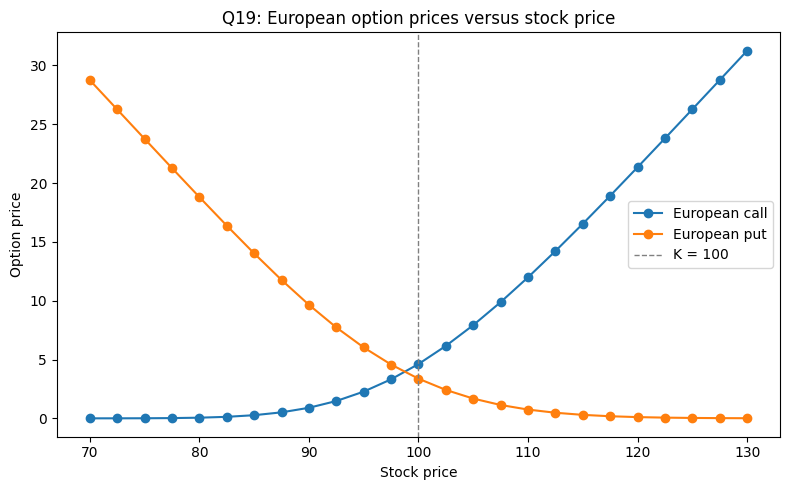

,stock price,call price,put price
0,70.000000,0.000000,28.760000
1,72.500000,0.000000,26.260000
2,75.000000,0.010000,23.770000
3,77.500000,0.020000,21.280000
4,80.000000,0.060000,18.810000


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(european_stock_grid_prices["stock price"], european_stock_grid_prices["call price"], marker="o", label="European call")
ax.plot(european_stock_grid_prices["stock price"], european_stock_grid_prices["put price"], marker="o", label="European put")
ax.axvline(GRAPH_STRIKE, color="gray", linestyle="--", linewidth=1, label="K = 100")
ax.set_title("Q19: European option prices versus stock price")
ax.set_xlabel("Stock price")
ax.set_ylabel("Option price")
ax.legend()
plt.tight_layout()
plt.show()

display(european_stock_grid_prices.assign(**{
    "call price": european_stock_grid_prices["call price"].round(2),
    "put price": european_stock_grid_prices["put price"].round(2),
}).head())


**Q19 answer.** The European call price rises as the stock price rises, while the European put price falls. That is the payoff logic showing up in the graph: calls want upside, puts want downside.


### Q20 — American call and put prices versus stock prices


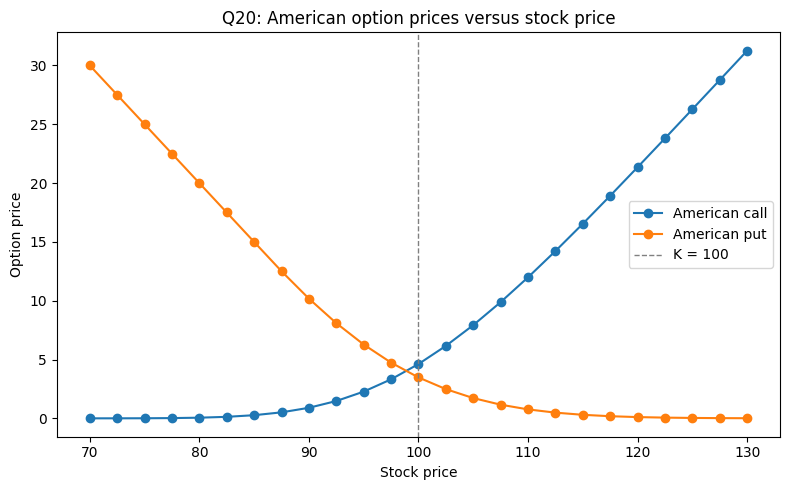

,stock price,call price,put price
0,70.000000,0.000000,30.000000
1,72.500000,0.000000,27.500000
2,75.000000,0.010000,25.000000
3,77.500000,0.020000,22.500000
4,80.000000,0.060000,20.000000


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(american_stock_grid_prices["stock price"], american_stock_grid_prices["call price"], marker="o", label="American call")
ax.plot(american_stock_grid_prices["stock price"], american_stock_grid_prices["put price"], marker="o", label="American put")
ax.axvline(GRAPH_STRIKE, color="gray", linestyle="--", linewidth=1, label="K = 100")
ax.set_title("Q20: American option prices versus stock price")
ax.set_xlabel("Stock price")
ax.set_ylabel("Option price")
ax.legend()
plt.tight_layout()
plt.show()

display(american_stock_grid_prices.assign(**{
    "call price": american_stock_grid_prices["call price"].round(2),
    "put price": american_stock_grid_prices["put price"].round(2),
}).head())


**Q20 answer.** The American call has the same shape as the European call in this no-dividend setting. The American put falls as the stock price rises, but it sits above the European put because early exercise can add value.


### Q21 — European and American call prices versus strike


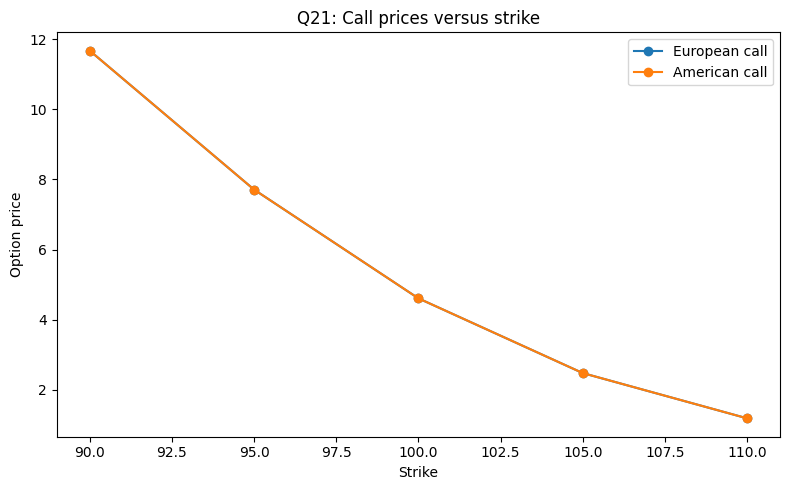

,strike,European call,American call
0,90.000000,11.670000,11.670000
1,95.000000,7.710000,7.710000
2,100.000000,4.610000,4.610000
3,105.000000,2.480000,2.480000
4,110.000000,1.190000,1.190000


In [22]:
call_strike_comparison = q15_answer[["strike", "price"]].rename(columns={"price": "European call"}).merge(
    q17_answer[["strike", "price"]].rename(columns={"price": "American call"}),
    on="strike",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(call_strike_comparison["strike"], call_strike_comparison["European call"], marker="o", label="European call")
ax.plot(call_strike_comparison["strike"], call_strike_comparison["American call"], marker="o", label="American call")
ax.set_title("Q21: Call prices versus strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Option price")
ax.legend()
plt.tight_layout()
plt.show()

display(call_strike_comparison)


**Q21 answer.** Both European and American call prices fall as the strike increases. In our no-dividend setup, the American and European call curves almost sit on top of each other because early exercise is not optimal.


### Q22 — European and American put prices versus strike


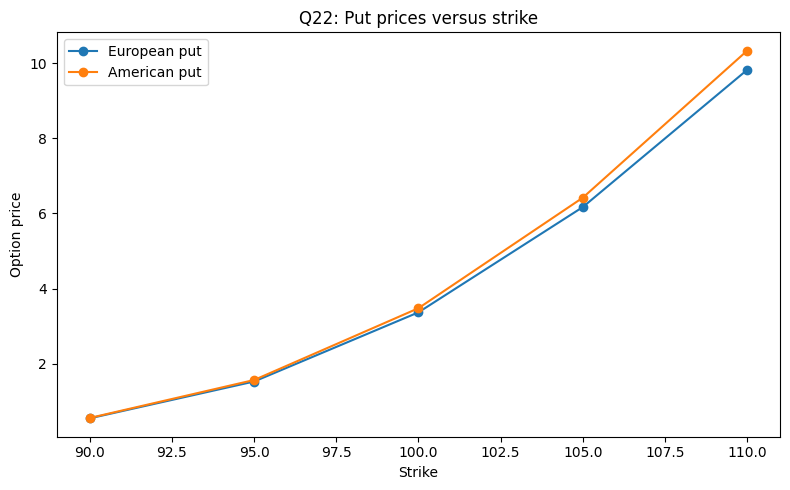

,strike,European put,American put
0,90.000000,0.550000,0.560000
1,95.000000,1.530000,1.570000
2,100.000000,3.370000,3.480000
3,105.000000,6.170000,6.420000
4,110.000000,9.820000,10.330000


In [23]:
put_strike_comparison = q16_answer[["strike", "price"]].rename(columns={"price": "European put"}).merge(
    q18_answer[["strike", "price"]].rename(columns={"price": "American put"}),
    on="strike",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(put_strike_comparison["strike"], put_strike_comparison["European put"], marker="o", label="European put")
ax.plot(put_strike_comparison["strike"], put_strike_comparison["American put"], marker="o", label="American put")
ax.set_title("Q22: Put prices versus strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Option price")
ax.legend()
plt.tight_layout()
plt.show()

display(put_strike_comparison)


**Q22 answer.** Put prices rise as the strike increases. The American put is above the European put for every strike because the holder has one extra choice: exercise before maturity when that is better than waiting.


### Q23 — European parity check for the five trinomial strikes

For each strike, we check:

\[
C_E + K e^{-rT} = P_E + S_0.
\]


In [24]:
q23_rows = []
for K in strikes:
    call = trinomial_tree_price(S0, K, r, sigma, T, TRINOMIAL_STEPS, "call", american=False)["price"]
    put = trinomial_tree_price(S0, K, r, sigma, T, TRINOMIAL_STEPS, "put", american=False)["price"]
    lhs = call + K * math.exp(-r * T)
    rhs = put + S0
    q23_rows.append({
        "strike": K,
        "European call": cents(call),
        "European put": cents(put),
        "C + K exp(-rT)": round(lhs, 6),
        "P + S0": round(rhs, 6),
        "difference": round(lhs - rhs, 8),
        "parity holds within 1 cent": abs(lhs - rhs) <= 0.01,
    })

q23_answer = pd.DataFrame(q23_rows)
display(q23_answer)


,strike,European call,European put,C + K exp(-rT),P + S0,difference,parity holds within 1 cent
0,90.000000,11.670000,0.550000,100.552248,100.552248,-0.000000,True
1,95.000000,7.710000,1.530000,101.534627,101.534627,-0.000000,True
2,100.000000,4.610000,3.370000,103.372278,103.372278,-0.000000,True
3,105.000000,2.480000,6.170000,106.173344,106.173344,-0.000000,True
4,110.000000,1.190000,9.820000,109.824804,109.824804,-0.000000,True


**Q23 answer.** Put-call parity holds for the European trinomial prices across all five strikes within normal rounding. We read this as a strong consistency check on the trinomial implementation.


### Q24 — American parity check for the five trinomial strikes

For American options, we check no-arbitrage bounds rather than strict equality:

\[
S_0-K \le C_A-P_A \le S_0-Ke^{-rT}.
\]


In [25]:
q24_rows = []
for K in strikes:
    call = trinomial_tree_price(S0, K, r, sigma, T, TRINOMIAL_STEPS, "call", american=True)["price"]
    put = trinomial_tree_price(S0, K, r, sigma, T, TRINOMIAL_STEPS, "put", american=True)["price"]
    spread = call - put
    lower = S0 - K
    upper = S0 - K * math.exp(-r * T)
    equality_difference = (call + K * math.exp(-r * T)) - (put + S0)
    q24_rows.append({
        "strike": K,
        "American call": cents(call),
        "American put": cents(put),
        "C_A - P_A": round(spread, 6),
        "lower bound": round(lower, 6),
        "upper bound": round(upper, 6),
        "bounds hold": lower - 1e-10 <= spread <= upper + 1e-10,
        "strict parity difference": round(equality_difference, 6),
    })

q24_answer = pd.DataFrame(q24_rows)
display(q24_answer)


,strike,American call,American put,C_A - P_A,lower bound,upper bound,bounds hold,strict parity difference
0,90.000000,11.670000,0.560000,11.107140,10.000000,11.117998,True,-0.010858
1,95.000000,7.710000,1.570000,6.141897,5.000000,6.180109,True,-0.038212
2,100.000000,4.610000,3.480000,1.134994,0.000000,1.242220,True,-0.107226
3,105.000000,2.480000,6.420000,-3.945715,-5.000000,-3.695669,True,-0.250046
4,110.000000,1.190000,10.330000,-9.139302,-10.000000,-8.633558,True,-0.505744


**Q24 answer.** The American options satisfy the no-arbitrage bounds, while the strict European parity equality does not generally hold. That is the right outcome because early exercise changes the American put value.


## Q25-Q27 - Dynamic Delta Hedging

For the hedging questions, we use the project parameters:

\[
S_0=180,\quad r=2\%,\quad \sigma=25\%,\quad T=0.5,\quad K=182.
\]

For a short option position, we hedge by holding the option Delta in shares:

\[
\text{shares held}=\Delta_{\text{option}}.
\]

Because put Deltas are negative, a put seller usually shorts shares to offset the stock exposure created by selling the put. The cash account tracks the option premium, stock trades, interest, and final payoff.


In [26]:
HEDGE_S0 = 180.0
HEDGE_R = 0.02
HEDGE_SIGMA = 0.25
HEDGE_T = 0.5
HEDGE_K = 182.0

def build_binomial_lattice(S0, K, r, sigma, T, steps, option_type, american=False):
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    disc = math.exp(-r * dt)
    p = (math.exp(r * dt) - d) / (u - d)

    stock_tree = []
    for step in range(steps + 1):
        j = np.arange(step + 1)
        stock_tree.append(S0 * (u ** j) * (d ** (step - j)))

    value_tree = [None] * (steps + 1)
    exercise_tree = [np.zeros(step + 1, dtype=bool) for step in range(steps + 1)]
    value_tree[steps] = payoff(stock_tree[steps], K, option_type)

    for step in range(steps - 1, -1, -1):
        continuation = disc * (p * value_tree[step + 1][1:] + (1 - p) * value_tree[step + 1][:-1])
        intrinsic = payoff(stock_tree[step], K, option_type)
        if american:
            value_tree[step] = np.maximum(continuation, intrinsic)
            exercise_tree[step] = (intrinsic > continuation + 1e-10) & (intrinsic > 0)
        else:
            value_tree[step] = continuation

    delta_tree = []
    for step in range(steps):
        numerator = value_tree[step + 1][1:] - value_tree[step + 1][:-1]
        denominator = stock_tree[step + 1][1:] - stock_tree[step + 1][:-1]
        delta_tree.append(numerator / denominator)

    return {
        "S0": S0,
        "K": K,
        "r": r,
        "sigma": sigma,
        "T": T,
        "steps": steps,
        "dt": dt,
        "u": u,
        "d": d,
        "p": p,
        "stock_tree": stock_tree,
        "value_tree": value_tree,
        "delta_tree": delta_tree,
        "exercise_tree": exercise_tree,
        "american": american,
        "option_type": option_type,
        "price": float(value_tree[0][0]),
    }


def hedge_short_option_on_path(lattice, path_moves):
    stock_tree = lattice["stock_tree"]
    value_tree = lattice["value_tree"]
    delta_tree = lattice["delta_tree"]
    exercise_tree = lattice["exercise_tree"]
    steps = lattice["steps"]
    dt = lattice["dt"]
    r = lattice["r"]
    K = lattice["K"]
    option_type = lattice["option_type"]
    american = lattice["american"]

    rows = []
    step = 0
    up_moves = 0
    stock = float(stock_tree[0][0])
    option_value = float(value_tree[0][0])
    shares = float(delta_tree[0][0])
    cash = option_value - shares * stock

    rows.append({
        "step": 0,
        "move": "start",
        "up moves": up_moves,
        "stock price": stock,
        "option value": option_value,
        "option delta": shares,
        "trade in shares": shares,
        "shares held after trade": shares,
        "cash account after trade": cash,
        "exercise event": False,
        "seller payoff paid": 0.0,
    })

    for move in path_moves:
        cash *= math.exp(r * dt)
        step += 1
        if move == "U":
            up_moves += 1
        elif move != "D":
            raise ValueError("Path moves must be 'U' or 'D'")

        stock = float(stock_tree[step][up_moves])
        option_value = float(value_tree[step][up_moves])

        exercise_now = bool(american and step < steps and exercise_tree[step][up_moves])
        if exercise_now:
            seller_payoff = float(payoff(stock, K, option_type))
            cash += shares * stock
            cash -= seller_payoff
            rows.append({
                "step": step,
                "move": move,
                "up moves": up_moves,
                "stock price": stock,
                "option value": option_value,
                "option delta": np.nan,
                "trade in shares": -shares,
                "shares held after trade": 0.0,
                "cash account after trade": cash,
                "exercise event": True,
                "seller payoff paid": seller_payoff,
            })
            break

        if step < steps:
            new_shares = float(delta_tree[step][up_moves])
            trade = new_shares - shares
            cash -= trade * stock
            shares = new_shares
            seller_payoff = 0.0
        else:
            trade = -shares
            seller_payoff = float(payoff(stock, K, option_type))
            cash += shares * stock
            cash -= seller_payoff
            shares = 0.0

        rows.append({
            "step": step,
            "move": move,
            "up moves": up_moves,
            "stock price": stock,
            "option value": option_value,
            "option delta": np.nan if step == steps else shares,
            "trade in shares": trade,
            "shares held after trade": shares,
            "cash account after trade": cash,
            "exercise event": False,
            "seller payoff paid": seller_payoff,
        })

    return pd.DataFrame(rows)


### Q25 — European put price and 3-step Delta hedge


In [27]:
euro_put_3 = build_binomial_lattice(
    HEDGE_S0, HEDGE_K, HEDGE_R, HEDGE_SIGMA, HEDGE_T, 3, "put", american=False
)

q25_path = ["D", "U", "D"]
q25_hedge = hedge_short_option_on_path(euro_put_3, q25_path)

q25_price_answer = pd.DataFrame([
    {
        "question": "Q25a",
        "option": "European put",
        "steps": 3,
        "S0": HEDGE_S0,
        "K": HEDGE_K,
        "price": cents(euro_put_3["price"]),
    }
])

display(q25_price_answer)
display(q25_hedge.round(4))


,question,option,steps,S0,K,price
0,Q25a,European put,3,180.000000,182.000000,13.820000


,step,move,up moves,stock price,option value,option delta,trade in shares,shares held after trade,cash account after trade,exercise event,seller payoff paid
0,0,start,0,180.000000,13.822400,-0.472600,-0.472600,-0.472600,98.882100,False,0.000000
1,1,D,0,162.535200,22.405600,-0.744700,-0.272200,-0.744700,143.452700,False,0.000000
2,2,U,1,180.000000,9.877800,-0.528800,0.215900,-0.528800,105.069900,False,0.000000
3,3,D,1,162.535200,19.464800,NaN,0.528800,0.000000,0.000000,False,19.464800


**Q25 answer.** The 3-step European put price is shown above, and the selected stock path is `D -> U -> D`. We are the seller of the put, so we hedge the short option by holding the put Delta in shares.

Since the put Delta is negative, our initial hedge is a short stock position. The cash account is the running bank account for the strategy: we receive the option premium, receive or pay cash when we trade shares, earn interest each period, and settle the option payoff at the end.

The point of the exercise is not that a 3-step tree is market-ready. It is a clean small example showing how Delta hedging works node by node.


### Q26 — American put Delta hedge with 25 steps

We now use the same inputs but price an American put with a 25-step binomial tree. The full node-level Delta table is computed and displayed below. The path-level hedge table then follows one selected path through the tree.


In [28]:
american_put_25 = build_binomial_lattice(
    HEDGE_S0, HEDGE_K, HEDGE_R, HEDGE_SIGMA, HEDGE_T, 25, "put", american=True
)

delta_node_rows = []
for step, deltas in enumerate(american_put_25["delta_tree"]):
    for up_moves, delta in enumerate(deltas):
        delta_node_rows.append({
            "step": step,
            "up moves": up_moves,
            "stock price": american_put_25["stock_tree"][step][up_moves],
            "option value": american_put_25["value_tree"][step][up_moves],
            "delta hedge shares": delta,
            "exercise region": bool(american_put_25["exercise_tree"][step][up_moves]),
        })

american_delta_nodes = pd.DataFrame(delta_node_rows)
american_delta_summary = american_delta_nodes.groupby("step").agg(
    min_delta=("delta hedge shares", "min"),
    max_delta=("delta hedge shares", "max"),
    mean_delta=("delta hedge shares", "mean"),
    exercise_nodes=("exercise region", "sum"),
).reset_index()

q26_path = list("DUDUUDDUDUUDDUDUUDUUDDUDU")
q26_hedge = hedge_short_option_on_path(american_put_25, q26_path)

q26_price_answer = pd.DataFrame([
    {
        "question": "Q26",
        "option": "American put",
        "steps": 25,
        "S0": HEDGE_S0,
        "K": HEDGE_K,
        "price": cents(american_put_25["price"]),
        "selected path": "".join(q26_path),
    }
])

display(q26_price_answer)
with pd.option_context("display.max_rows", 400, "display.max_columns", None):
    display(american_delta_nodes.round(4))
display(american_delta_summary.round(4))
display(q26_hedge.round(4))


,question,option,steps,S0,K,price,selected path
0,Q26,American put,25,180.000000,182.000000,13.040000,DUDUUDDUDUUDDUDUUDUUDDUDU


,step,up moves,stock price,option value,delta hedge shares,exercise region
0,0,0,180.000000,13.035700,-0.475600,False
1,1,0,173.747200,16.048700,-0.560800,False
2,1,1,186.477800,9.994600,-0.395100,False
3,2,0,167.711700,19.478900,-0.647900,False
4,2,1,180.000000,12.587500,-0.478600,False
5,2,2,193.188700,7.376500,-0.316300,False
6,3,0,161.885700,23.304700,-0.733100,False
7,3,1,173.747200,15.619800,-0.567500,False
8,3,2,186.477800,9.526600,-0.394700,False
9,3,3,200.141200,5.204900,-0.242300,False


,step,min_delta,max_delta,mean_delta,exercise_nodes
0,0,-0.475600,-0.475600,-0.475600,0
1,1,-0.560800,-0.395100,-0.478000,0
2,2,-0.647900,-0.316300,-0.480900,0
3,3,-0.733100,-0.242300,-0.484400,0
4,4,-0.812400,-0.176000,-0.488200,0
5,5,-0.882200,-0.120000,-0.492200,0
6,6,-0.940000,-0.075800,-0.496200,0
7,7,-0.984400,-0.043500,-0.500100,0
8,8,-1.000000,-0.022100,-0.502100,1
9,9,-1.000000,-0.009600,-0.503100,2


,step,move,up moves,stock price,option value,option delta,trade in shares,shares held after trade,cash account after trade,exercise event,seller payoff paid
0,0,start,0,180.000000,13.035700,-0.475600,-0.475600,-0.475600,98.635900,False,0.000000
1,1,D,0,173.747200,16.048700,-0.560800,-0.085200,-0.560800,113.487200,False,0.000000
2,2,U,1,180.000000,12.587500,-0.478600,0.082200,-0.478600,98.740600,False,0.000000
3,3,D,1,173.747200,15.619800,-0.567500,-0.088900,-0.567500,114.225200,False,0.000000
4,4,U,2,180.000000,12.116900,-0.481900,0.085600,-0.481900,98.865900,False,0.000000
5,5,U,3,186.477800,9.034600,-0.394100,0.087800,-0.394100,82.533800,False,0.000000
6,6,D,3,180.000000,11.620800,-0.485600,-0.091400,-0.485600,99.022900,False,0.000000
7,7,D,3,173.747200,14.696500,-0.583400,-0.097800,-0.583400,116.060600,False,0.000000
8,8,U,4,180.000000,11.095100,-0.489600,0.093800,-0.489600,99.223700,False,0.000000
9,9,D,4,173.747200,14.196200,-0.593100,-0.103500,-0.593100,117.247600,False,0.000000


**Q26 answer.** We price the American put with a 25-step tree and compute hedge Deltas at every non-terminal node. The full node table is long, so the summary table reports the Delta range by step and flags whether early-exercise nodes appear.

Compared with the European case, the American hedge is less smooth near exercise regions. That makes sense: once immediate exercise becomes possible, the option value can change shape quickly. As the put seller, we still generally hold a negative stock position, but the hedge can jump more sharply around nodes where exercise becomes relevant.

We should not compare the 3-step European price in Q25 and the 25-step American price in Q26 as if they used the same resolution. Q25 is a small teaching tree for the hedge mechanics. Q26 uses more steps because American exercise needs a richer grid.


### Q27 — Asian ATM put using Monte Carlo and pathwise Delta hedging

The Asian put payoff depends on the arithmetic average of the stock path:

\[
\max(K-\bar{S},0), \qquad \bar{S}=\frac{1}{N+1}\sum_{i=0}^{N}S_i.
\]

Because the payoff is path-dependent, a recombining tree no longer stores enough information by stock price alone. Following the course methodology for path-dependent options, we use Monte Carlo simulation. For the hedge table, we estimate conditional values and Deltas along one selected path using common random numbers and finite differences.


In [29]:
ASIAN_K = HEDGE_S0
ASIAN_STEPS = 25
ASIAN_MC_SIMS = 20000
ASIAN_DELTA_SIMS = 8000

def crr_params(r, sigma, T, steps):
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp(r * dt) - d) / (u - d)
    return dt, u, d, p


def asian_put_mc_price(S0, K, r, sigma, T, steps, sims=20000, seed=42):
    dt, u, d, p = crr_params(r, sigma, T, steps)
    rng = np.random.default_rng(seed)
    up = rng.binomial(1, p, size=(sims, steps))
    factors = np.where(up == 1, u, d)
    future_prices = S0 * np.cumprod(factors, axis=1)
    all_prices = np.concatenate([np.full((sims, 1), S0), future_prices], axis=1)
    averages = all_prices.mean(axis=1)
    payoffs = np.maximum(K - averages, 0.0)
    return math.exp(-r * T) * float(payoffs.mean())


def conditional_asian_value_delta(past_prices, current_stock, K, r, sigma, T, steps, current_step, sims=8000, seed=123, bump=0.01):
    dt, u, d, p = crr_params(r, sigma, T, steps)
    remaining = steps - current_step
    time_remaining = remaining * dt

    past_prices = np.asarray(past_prices, dtype=float)
    fixed_past_sum = float(past_prices[:-1].sum()) if len(past_prices) > 1 else 0.0

    if remaining == 0:
        avg = (fixed_past_sum + current_stock) / (steps + 1)
        value = max(K - avg, 0.0)
        delta = -1.0 / (steps + 1) if K > avg else 0.0
        return value, delta

    rng = np.random.default_rng(seed)
    up = rng.binomial(1, p, size=(sims, remaining))
    factors = np.where(up == 1, u, d)
    cumulative_factors = np.cumprod(factors, axis=1)

    def value_for(stock):
        future_prices = stock * cumulative_factors
        current_and_future_sum = stock + future_prices.sum(axis=1)
        averages = (fixed_past_sum + current_and_future_sum) / (steps + 1)
        payoffs = np.maximum(K - averages, 0.0)
        return math.exp(-r * time_remaining) * float(payoffs.mean())

    up_value = value_for(current_stock + bump)
    down_value = value_for(current_stock - bump)
    base_value = value_for(current_stock)
    delta = (up_value - down_value) / (2 * bump)
    return base_value, delta


def path_prices_from_moves(S0, r, sigma, T, steps, moves):
    dt, u, d, p = crr_params(r, sigma, T, steps)
    prices = [S0]
    stock = S0
    for move in moves:
        stock *= u if move == "U" else d
        prices.append(stock)
    return np.array(prices)


def asian_short_put_hedge_path(S0, K, r, sigma, T, steps, moves, sims=8000):
    dt, _, _, _ = crr_params(r, sigma, T, steps)
    prices = path_prices_from_moves(S0, r, sigma, T, steps, moves)
    rows = []

    value, delta = conditional_asian_value_delta(
        prices[:1], prices[0], K, r, sigma, T, steps, 0, sims=sims, seed=700
    )
    shares = delta
    cash = value - shares * prices[0]

    rows.append({
        "step": 0,
        "move": "start",
        "stock price": prices[0],
        "running average": prices[:1].mean(),
        "Asian put value": value,
        "estimated delta": delta,
        "trade in shares": shares,
        "shares held after trade": shares,
        "cash account after trade": cash,
        "seller payoff paid": 0.0,
    })

    for step, move in enumerate(moves, start=1):
        cash *= math.exp(r * dt)
        stock = prices[step]
        running_average = prices[: step + 1].mean()

        if step < steps:
            value, new_delta = conditional_asian_value_delta(
                prices[: step + 1],
                stock,
                K,
                r,
                sigma,
                T,
                steps,
                step,
                sims=sims,
                seed=700 + step,
            )
            trade = new_delta - shares
            cash -= trade * stock
            shares = new_delta
            payoff_paid = 0.0
        else:
            value = max(K - running_average, 0.0)
            new_delta = np.nan
            trade = -shares
            cash += shares * stock
            payoff_paid = value
            cash -= payoff_paid
            shares = 0.0

        rows.append({
            "step": step,
            "move": move,
            "stock price": stock,
            "running average": running_average,
            "Asian put value": value,
            "estimated delta": new_delta,
            "trade in shares": trade,
            "shares held after trade": shares,
            "cash account after trade": cash,
            "seller payoff paid": payoff_paid,
        })

    return pd.DataFrame(rows)


asian_price = asian_put_mc_price(
    HEDGE_S0, ASIAN_K, HEDGE_R, HEDGE_SIGMA, HEDGE_T, ASIAN_STEPS, sims=ASIAN_MC_SIMS, seed=42
)
asian_hedge = asian_short_put_hedge_path(
    HEDGE_S0, ASIAN_K, HEDGE_R, HEDGE_SIGMA, HEDGE_T, ASIAN_STEPS, q26_path, sims=ASIAN_DELTA_SIMS
)

q27_answer = pd.DataFrame([
    {
        "question": "Q27",
        "option": "Asian ATM put",
        "steps": ASIAN_STEPS,
        "strike": ASIAN_K,
        "MC simulations for price": ASIAN_MC_SIMS,
        "price": cents(asian_price),
        "regular American put price from Q26": cents(american_put_25["price"]),
    }
])

display(q27_answer)
display(asian_hedge.round(4))


,question,option,steps,strike,MC simulations for price,price,regular American put price from Q26
0,Q27,Asian ATM put,25,180.000000,20000,6.870000,13.040000


,step,move,stock price,running average,Asian put value,estimated delta,trade in shares,shares held after trade,cash account after trade,seller payoff paid
0,0,start,180.000000,180.000000,6.853500,-0.464600,-0.464600,-0.464600,90.485500,0.000000
1,1,D,173.747200,176.873600,9.379300,-0.573300,-0.108700,-0.573300,109.406900,0.000000
2,2,U,180.000000,177.915700,6.116400,-0.423900,0.149400,-0.423900,82.558900,0.000000
3,3,D,173.747200,176.873600,8.855400,-0.547700,-0.123800,-0.547700,104.094900,0.000000
4,4,U,180.000000,177.498900,5.565500,-0.406700,0.141000,-0.406700,78.764000,0.000000
5,5,U,186.477800,178.995400,3.057600,-0.267900,0.138800,-0.267900,52.913700,0.000000
6,6,D,180.000000,179.138900,4.680700,-0.372000,-0.104000,-0.372000,71.663200,0.000000
7,7,D,173.747200,178.464900,6.911300,-0.464600,-0.092600,-0.464600,87.787500,0.000000
8,8,U,180.000000,178.635500,4.051800,-0.330900,0.133700,-0.330900,63.761700,0.000000
9,9,D,173.747200,178.146700,6.136900,-0.427000,-0.096000,-0.427000,80.474400,0.000000


**Q27 answer.** The Asian ATM put is cheaper than the regular American put in Q26. This is not a perfect one-for-one comparison because the Asian ATM put uses \(K=180\), while Q26 uses \(K=182\). Even with that caveat, the direction makes financial sense.

Two forces push the Asian price lower. First, the Asian payoff uses an average stock price, so one sharp down move does not hit the payoff as hard as it would for a vanilla put. Second, the Asian put here is treated as a maturity-payoff path-dependent option, while the American put includes early exercise.

The hedge is also smoother because the running average dampens any single stock-price move. We should still treat the hedge as approximate because the Asian Delta is estimated by Monte Carlo finite differences, not read exactly from a recombining vanilla option tree.


## Final Conclusions

We can summarize the project in five points:

1. European put-call parity holds cleanly for the European option prices we compute.
2. American options need no-arbitrage bounds rather than the strict European parity equality.
3. In a no-dividend stock, American calls match European calls, while American puts can be more valuable because early exercise may help.
4. Delta hedging is a rebalancing process, not a single trade placed at time zero.
5. Path-dependent options such as Asian puts need simulation or a larger state space because the stock price alone does not determine the payoff.

Overall, the numerical results match the financial intuition: the models are not just producing numbers; they are producing the shapes and inequalities we should expect from option theory.


## References

- Black, F., and Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy.
- Cox, J. C., Ross, S. A., and Rubinstein, M. (1979). *Option Pricing: A Simplified Approach*. Journal of Financial Economics.
- Hull, J. C. *Options, Futures, and Other Derivatives*. Standard reference for binomial trees, American exercise, and Greeks.
- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Reference for simulation-based pricing and path-dependent derivatives.
- WorldQuant University, MSCFEE 620 Derivative Pricing course materials.


